# Task 1: Подберите параметры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.

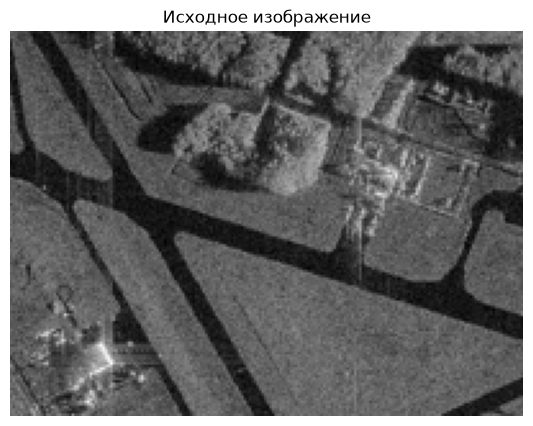

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_gray = cv2.resize(image_gray, (0, 0), fx=0.5, fy=0.5)
plt.figure(figsize=(7,5))
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off');

# Разрастание регионов

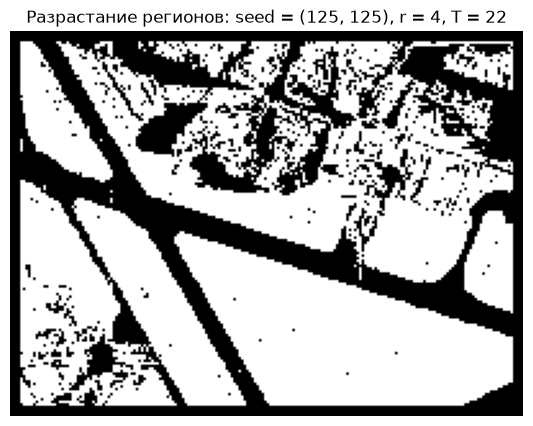

In [2]:
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])
    if abs(av_val - img[point]) <= T:
        return True
    return False

def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image_gray.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image_gray.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i,j] == 0 and mask[i-r:i+r, j-r:j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        mask += local_mask
    return mask * 255

seed_point = (125, 125)
r = 4
T = 22
mask_avg = region_growing(image_gray, seed_point, homo_average, r, T)

plt.figure(figsize=(7,5))
plt.imshow(mask_avg, cmap='gray')
plt.title(f'Разрастание регионов: seed = {seed_point}, r = {r}, T = {T}')
plt.axis('off');

# Task 2: Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.

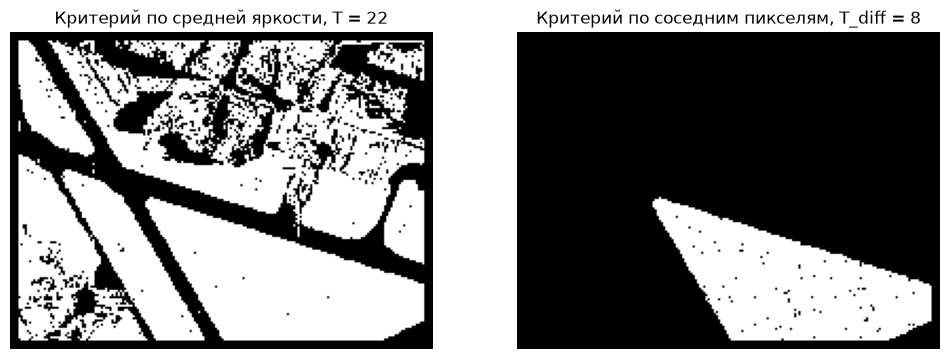

In [3]:
def homo_neighbor(img, mask, point, T_diff):
    i, j = point
    current = int(img[point])
    local = img[i-1:i+2, j-1:j+2]
    local_mask = mask[i-1:i+2, j-1:j+2] > 0
    neighbors = local[local_mask]
    if neighbors.size == 0:
        return False
    return np.any(np.abs(neighbors.astype(np.int16) - current) <= T_diff)

T_diff = 8
mask_neighbor = region_growing(image_gray, seed_point, homo_neighbor, r, T_diff)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(mask_avg, cmap='gray')
plt.title('Критерий по средней яркости, T = 22')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(mask_neighbor, cmap='gray')
plt.title('Критерий по соседним пикселям, T_diff = 8')
plt.axis('off');

# Task 3: Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

Используется последовательность: бинаризация -> distance transform -> выделение уверенных областей -> watershed.

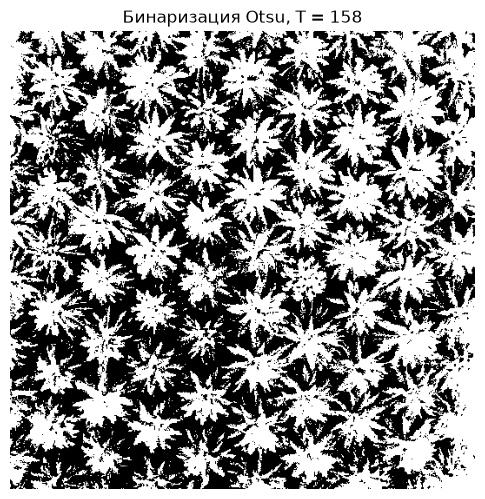

In [4]:
palm = cv2.imread('palm_1.jpg')
palm_gray = cv2.cvtColor(palm, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(palm_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap='gray')
plt.title(f'Бинаризация Otsu, T = {ret:.0f}')
plt.axis('off');

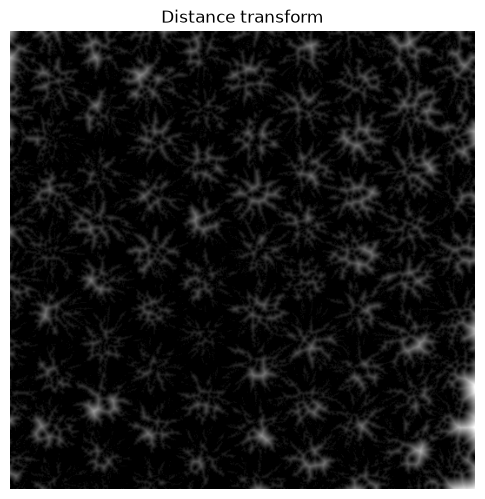

In [5]:
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)

plt.figure(figsize=(6,6))
plt.imshow(dist, cmap='gray')
plt.title('Distance transform')
plt.axis('off');

Количество найденных центров: 52


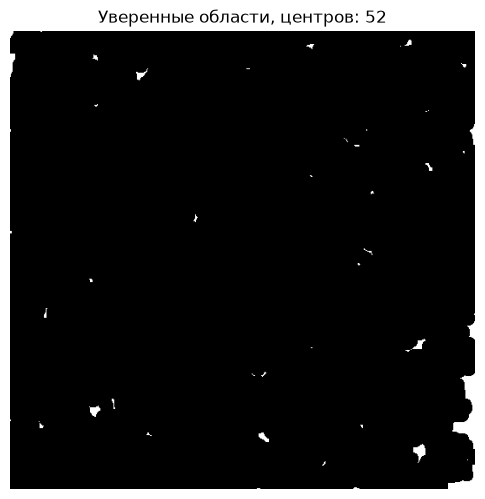

In [6]:
ret, sure_fg = cv2.threshold(dist, 0.4 * dist.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)
ret, markers = cv2.connectedComponents(sure_fg)
palm_count = ret - 1
print('Количество найденных центров:', palm_count)

plt.figure(figsize=(6,6))
plt.imshow(sure_fg, cmap='gray')
plt.title(f'Уверенные области, центров: {palm_count}')
plt.axis('off');

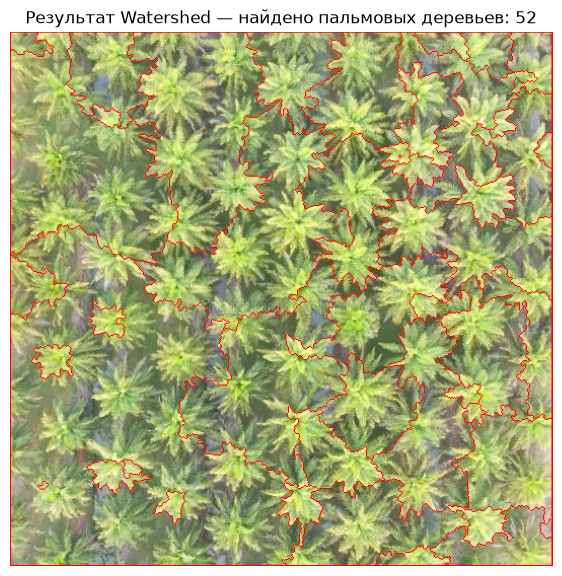

In [9]:
markers = cv2.watershed(palm, markers)
result = palm.copy()
result[markers == -1] = [0, 0, 255]

plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f'Результат Watershed — найдено пальмовых деревьев: {palm_count}')
plt.axis('off');